## EDA - Explorative Data Analysis
- Undersökning av datan

In [1]:
import pandas as pd

df = pd.read_csv('cardio_train.csv',delimiter=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [2]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Några slutsatser
- Det finns fler kvinnor i datasetet, medelvärdet för kön är närmare 1, vilket är etiketten för kvinnor.
- Den genomsnittliga personen är 19 468 / 365 = 53,3 år gammal, och inom en standardavvikelse kan åldern variera med ± 2 467 / 365 = 6,7 år.
- Majoriteten av personer i datan tillhör den något äldre medelålderskategorin.


In [3]:
#percentage of number that has cardio sickness
len(df[df['cardio'] == 1]) / len(df)

0.4997

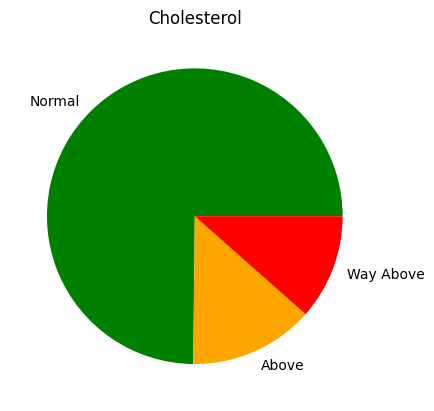

In [4]:
import matplotlib.pyplot as plt
chol = df['cholesterol']
normal = chol[chol == 1]
above = chol[chol == 2]
well_above = chol[chol == 3]
plt.pie([len(normal),len(above), len(well_above)], labels=['Normal', 'Above', 'Way Above'], colors=['green', 'orange', 'red'])
plt.title('Cholesterol')
plt.show()

<Axes: >

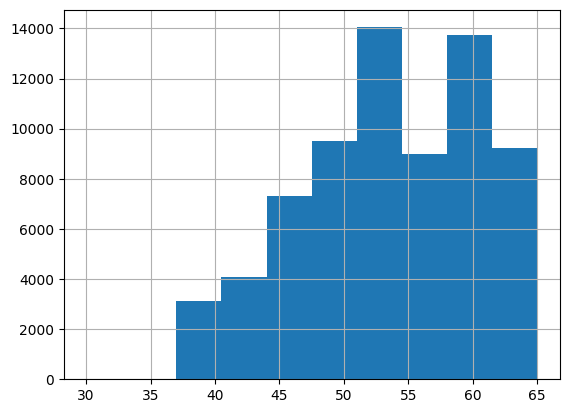

In [5]:
#Åldersfördelning
age = df['age'].apply(lambda x: round(x / 365))
age.hist()

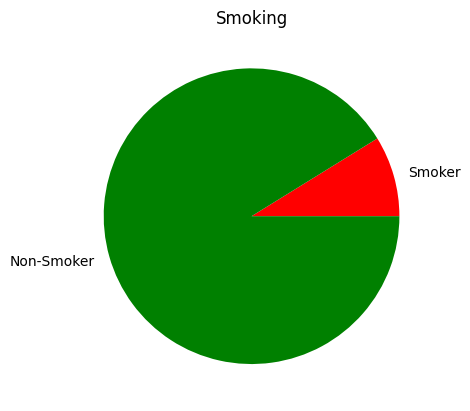

In [6]:
#Rökare
yes_smoke = df['smoke'][df['smoke'] == 1]
no_smoke = df['smoke'][df['smoke'] == 0]

plt.pie([len(yes_smoke), len(no_smoke)], labels=['Smoker', 'Non-Smoker'], colors=['red', 'green'])
plt.title('Smoking')
plt.show()

<Axes: >

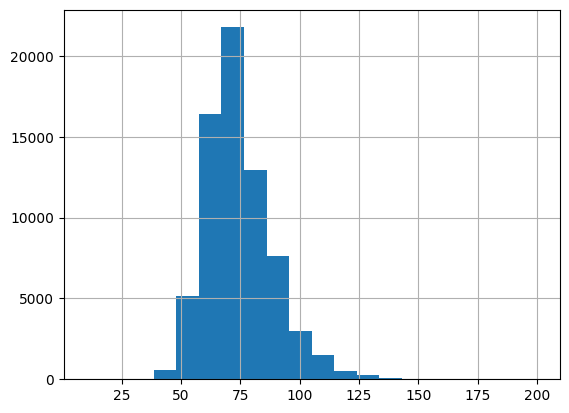

In [7]:
#weight
df['weight'].hist(bins=20)

<Axes: >

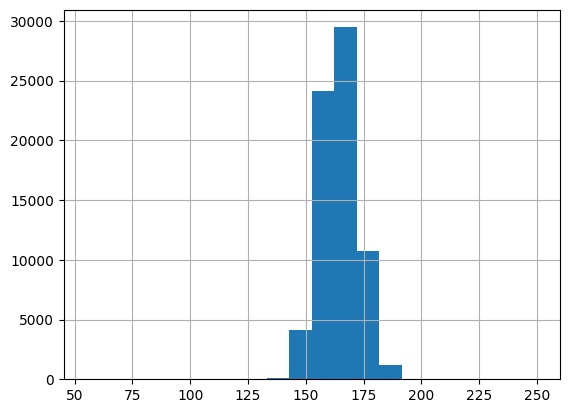

In [8]:
#Height
df['height'].hist(bins=20)

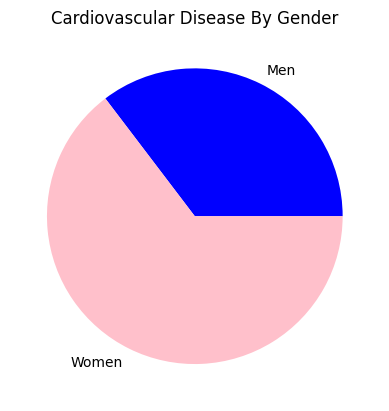

In [9]:
cardio = df[df['cardio'] == 1]
men = cardio[cardio['gender'] == 2]
women = cardio[cardio['gender'] == 1]
plt.pie([len(men), len(women)], labels=['Men', 'Women'], colors=['blue', 'pink'])
plt.title('Cardiovascular Disease By Gender')
plt.show()

- Rensad data finns i revised_data.csv och städningen ligger i Feature_Engineering
- Fortsatt analys på nyskapade kategorierna 
### Sjukdomar jämfört mot Blodtryckskategori, BMI, Rökare

Text(0.5, 1.0, 'Cardio sick and Smokers')

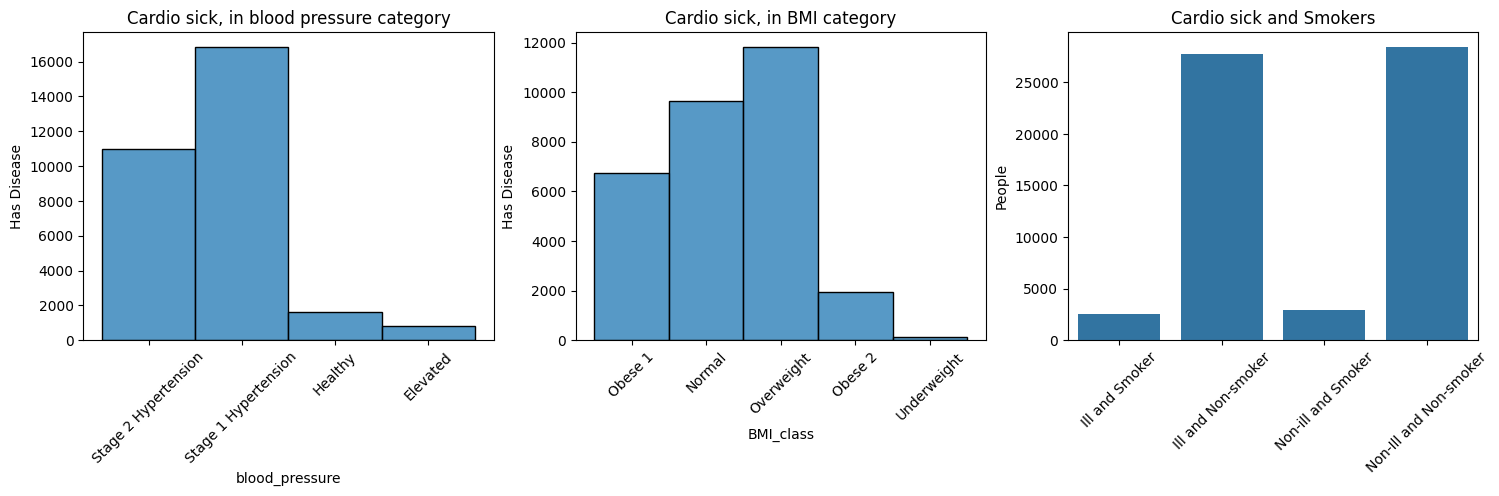

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('revised_data.csv', index_col=0)
ill_true = df[df['cardio'] == 1]
fig, axes = plt.subplots(1,3)
fig.set_size_inches(18,4)
#rotera labels
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='x', rotation=45)

#Antal sjuka per blodkategori
sns.histplot(ill_true['blood_pressure'], ax=axes[0])
axes[0].set(ylabel = 'Has Disease')
axes[0].set_title('Cardio sick, in blood pressure category')

#Antal sjuka per BMI-kategori
sns.histplot(ill_true['BMI_class'], ax=axes[1])
axes[1].set(ylabel = 'Has Disease')
axes[1].set_title('Cardio sick, in BMI category')

#Jämför Rökare om de har hjärtsjukdomar eller inte
sns.barplot([len(df[(df['cardio'] == 1) & (df['smoke'] == 1)]), 
            len(df[(df['cardio'] == 1) & (df['smoke'] == 0)]), 
            len(df[(df['cardio'] == 0) & (df['smoke'] == 1)]),
            len(df[(df['cardio'] == 0) & (df['smoke'] == 0)])],
            ax=axes[2])

axes[2].set(ylabel = 'People')
axes[2].set_xticks(ticks= [0,1,2,3], labels=['Ill and Smoker', 'Ill and Non-smoker', 'Non-ill and Smoker', 'Non-Ill and Non-smoker'])
axes[2].set_title('Cardio sick and Smokers')


### Korrelation

<Axes: >

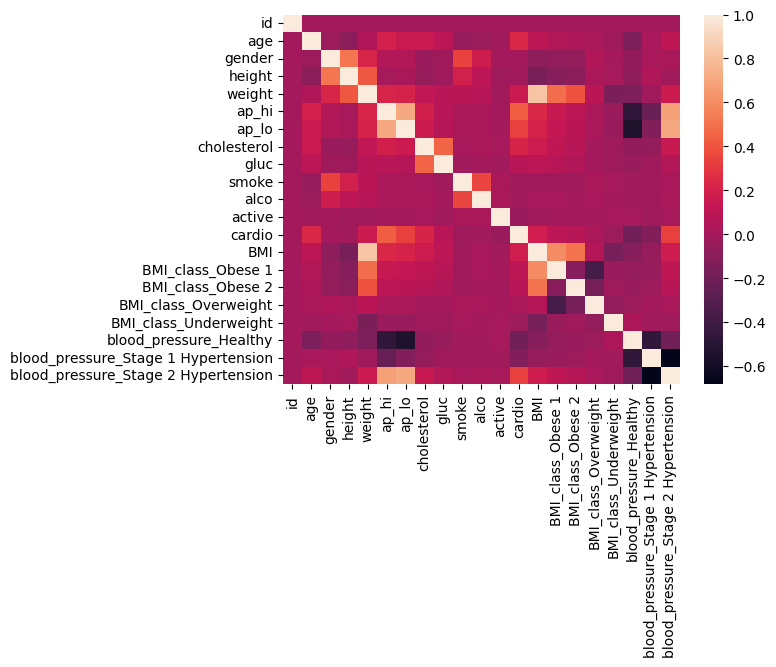

In [11]:
dummies = pd.get_dummies(df, drop_first=True)
sns.heatmap(dummies.corr())

### Slutsats
- De största korrelationerna finns mellan skapade Features som är skapade av originaldatan vilket är rimligt
- BMI har stark korrelation med weight, inte så konstigt eftersom weight är en beroende variabel till att räkna ut BMI
- ap_hi och ap_lo (systoliskt och diastoliskt blodtryck) har stark korrelation med blood_pressure kategorierna. Även dessa kategorier är beroende av ap_hi och ap_lo.

### Skapar dataset med och utan de kategoriska features

In [12]:
import pandas as pd
df = pd.read_csv('revised_data.csv', index_col=0)
df = df.drop(columns='id') # Tar bort id eftersom id = index, onödig feature
df['gender'] = df['gender'].apply(lambda x: 'Woman' if x == 1 else 'Man') # Eftersom det är en kategorisk variabel gör jag den mer läsbar
yes_cat = df.drop(columns=[ 'ap_hi', 'ap_lo', 'height', 'weight', 'BMI'])
no_cat = df.drop(columns=['BMI_class', 'blood_pressure', 'height', 'weight'])

#One hot encoding
yes_cat = pd.get_dummies(yes_cat, columns=['BMI_class', 'blood_pressure', 'gender'])
no_cat = pd.get_dummies(no_cat, columns=['gender'])


### Använder custom class för att ta fram modeller att testa datan

In [13]:
from model_class import model_selection
#Initierar två klasser med och utan kategoriska features
X = yes_cat.drop(columns='cardio')
y = yes_cat['cardio']
#Initierar med skalering och test_split funktion
with_cat = model_selection(X, y, autoscale=True, autosplit=True)
X = no_cat.drop(columns='cardio')
y = no_cat['cardio']
#Initierar med skalering och test_split funktion
without_cat = model_selection(X, y, autoscale=True, autosplit=True)


## Val av modeller
##### Eftersom detta är ett kvalificeringsproblem väljer jag följande:
- KNN
- Logistisk Regression
- Decision Trees
- Ridge Classifier
- RandomForestClassifier

In [ ]:
#Skapar Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Ihopklistrad och omskriven kod. Ursprungligen från ChatGpt och sklearn
#Valde dessa modeller eftersom de skiljer sig åt deras funktion, de som möjligtvis påminner om varandra är RandomForest och DecisionTrees
#Jag försökte hålla mig till få parametrar för att minska beräkningstiden.
param_grid = [
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [1,3],
    },
    {
        'classifier': [LogisticRegression()],
        'classifier__C': [0.01, 0.1, 1]
    },
    {
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [1,2]
    },
    {
        'classifier': [RidgeClassifier()],
        'classifier__alpha': [0.01, 0.1, 1]
    },
    {
        'classifier': [RandomForestClassifier()],
        'classifier__max_depth': [1, 2],
    }
]
print('With Categories:')
with_cat.GridCV_pipeline_fit(param_grid=param_grid)
print('Without Categories:')
without_cat.GridCV_pipeline_fit(param_grid=param_grid)
#Tar ca 50 sekunder, RandomForest är långsam på cpu

With Categories:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa modellen: Pipeline(steps=[('classifier', RidgeClassifier(alpha=0.1))])
Bästa score: 0.695348044367648
Without Categories:
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa modellen: Pipeline(steps=[('classifier', LogisticRegression(C=1))])
Bästa score: 0.7249733530279195


With category
              precision    recall  f1-score   support

           0       0.67      0.78      0.72     10311
           1       0.73      0.60      0.66     10039

    accuracy                           0.69     20350
   macro avg       0.70      0.69      0.69     20350
weighted avg       0.70      0.69      0.69     20350

Without category
              precision    recall  f1-score   support

           0       0.70      0.79      0.74     10360
           1       0.74      0.65      0.69      9990

    accuracy                           0.72     20350
   macro avg       0.72      0.72      0.72     20350
weighted avg       0.72      0.72      0.72     20350



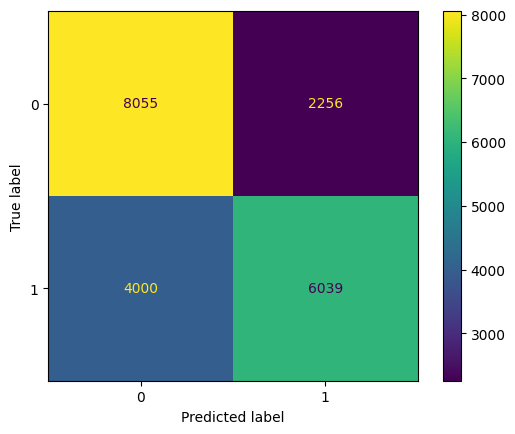

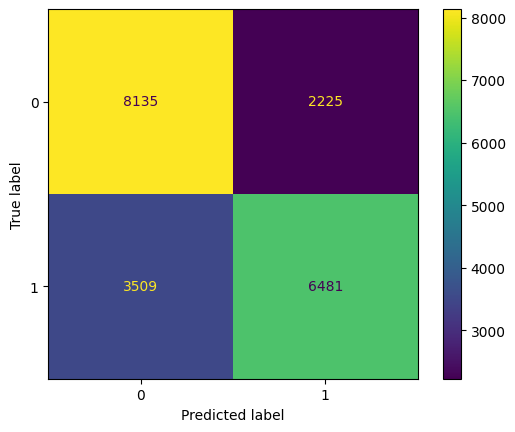

In [15]:
#Förutse y_hat från X_test
print('With category')
with_cat.predict_score()
print('Without category')
without_cat.predict_score()

- Eftersom datasetet utan kategorier har presterat bättre både i träning och i validering väljer jag att fortsätta med den

In [16]:
#Hämtar bästa parametrar för varje model
score_withoutcat = without_cat.get_all_best_params()

print(score_withoutcat)

{'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 3}, score: 0.6744119829248498
{'classifier': LogisticRegression(), 'classifier__C': 1}, score: 0.7249733530279195
{'classifier': DecisionTreeClassifier(), 'classifier__max_depth': 1}, score: 0.7110803223738851
{'classifier': RidgeClassifier(), 'classifier__alpha': 0.01}, score: 0.7228434082396961
{'classifier': RandomForestClassifier(), 'classifier__max_depth': 2}, score: 0.7129198655432099



- Nu är de bästa parametrar kända från CrossValidation och sätter in dessa i en VoteClassifier

In [17]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
vclf = VotingClassifier(
    [('knn', KNeighborsClassifier(n_neighbors=3)),
     ('logr',LogisticRegression(C=1)),
     ('dtree', DecisionTreeClassifier(max_depth=1)),
     ('Rreg', RidgeClassifier(alpha=0.01)),
     ('Rforest', RandomForestClassifier(max_depth=2))], voting='hard'
)
vclf.fit(without_cat.X_train, without_cat.y_train)
y_hat = vclf.predict(without_cat.X_test)
print(classification_report(without_cat.y_test, y_hat))

              precision    recall  f1-score   support

           0       0.70      0.79      0.74     10360
           1       0.75      0.64      0.69      9990

    accuracy                           0.72     20350
   macro avg       0.72      0.72      0.72     20350
weighted avg       0.72      0.72      0.72     20350



### Slutsatser
- Voting Classifier resultera i något sämre accuracy än Logistic Regression som Crossvalidation tog fram med bästa hyperparameter.
- Analysen utifrån resultatet är att en Voting Classifier kan försämra accuracy om du inkluderar modeller med sämre accuracy även för att få en "bredare uppfattning"
- Därför kan det vara rimligt att hålla sig till en modell som är överlägsen andra modeller.
- Om man däremot har modeller som presterar lika bra kan Voting Classifier vara att föredra.
- I detta fall var den ej kategoriska datan mer relevant och även den modell som prestera bäst var Logistic Regression med den valda C=1.


### Slutresultat

              precision    recall  f1-score   support

           0       0.70      0.79      0.74     10360
           1       0.74      0.65      0.69      9990

    accuracy                           0.72     20350
   macro avg       0.72      0.72      0.72     20350
weighted avg       0.72      0.72      0.72     20350



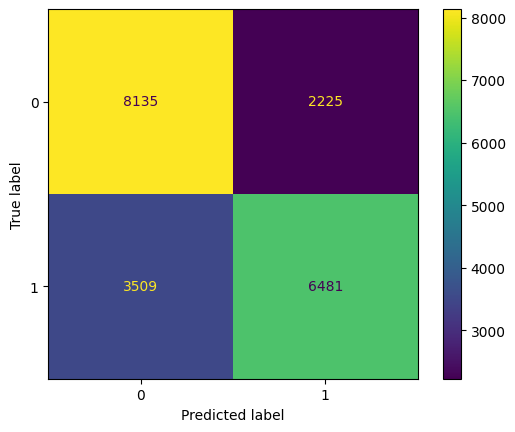

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model = LogisticRegression(C=1)
model.fit(without_cat.X_train, without_cat.y_train)
y_hat = model.predict(without_cat.X_test)
cm = confusion_matrix(without_cat.y_test, y_hat)
ConfusionMatrixDisplay(cm).plot()
print(classification_report(without_cat.y_test, y_hat))